In [46]:
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import geopandas as gpd
import regionmask
from shapely.geometry import box
import matplotlib.image as mpimg
import string

In [22]:
#Define shape of biogeographical boarder of Amazon + Equator as northern boarder

amazon = gpd.read_file("/projekt1/ag_maahn/data_obs_nobackup/amazonas/shape/biogeo/Lim_Biogeografico.shp")
south_box = box(-85, -25, -30, 0)   # (minx, miny, maxx, maxy)
amazon_south = gpd.clip(amazon, south_box)

In [23]:
SG=18 #fontsize
sets=['CWP_liq.nc','CMF_low.nc', 'COT_liq.nc', 'CPS_liq.nc']

In [24]:
#ENSO Data

df = pd.read_csv("meiv2.data" , sep=r'\s+' , header=0 , skipfooter=4 , engine='python' , na_values=[-999, -999.0])
df.columns = ["year", "DJ", "JF", "FM", "MA", "AM", "MJ", "JJ", "JA", "AS", "SO", "ON", "ND"]
season_to_month = {
    "DJ": 1, "JF": 2, "FM": 3, "MA": 4, "AM": 5, "MJ": 6,
    "JJ": 7, "JA": 8, "AS": 9, "SO": 10, "ON": 11, "ND": 12
}
iod          = df.melt(id_vars="year", var_name="season", value_name="mei")
iod["month"] = iod["season"].map(season_to_month)
iod["date"]  = pd.to_datetime(iod[["year", "month"]].assign(day=1))
iod          = iod.dropna(subset=["mei"]).sort_values("date")

# Hansen Forest Data

In [25]:
#load lossyear dataset

path='/projekt1/ag_maahn/data_obs_nobackup/amazonas/forest_loss/'

kacheln1 = [
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_080W.tif")
]
mrd1 = merge_arrays(kacheln1)

In [26]:
#load treecover2000 dataset

path2='/projekt1/ag_maahn/data_obs_nobackup/amazonas/cover2000/'

kacheln2 = [
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_080W.tif")
]

mrd2 =merge_arrays(kacheln2)

In [27]:
#merge both forest datasets together

loss = mrd1.to_dataset(name="lossyear")
cvr = mrd2.to_dataset(name="cover2000")
ds=xr.merge([loss, cvr])

/tmp/ipykernel_2334905/451643577.py:5: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds=xr.merge([loss, cvr])


In [28]:
# set boundary values for map-plots
lon_min, lon_max = -79,-43#-80, -42
lat_min, lat_max = -18,0#-20, 5

In [29]:
th=30 # % Threshold for beeing marked as forest

maxX = round(float(ds['x'].max()),0)
minX = round(float(ds['x'].min()),0)

maxY = round(float(ds['y'].max()),0)
minY = round(float(ds['y'].min()),0)

In [30]:
#Determine deforested pixels

# 1. create bolean arrays & create baseline 2001 dataset
cond_forest = (ds['cover2000'] >= th) & ((ds['lossyear'] >= 2) | (ds['lossyear'] == 0))
cond_no_loss = ds['lossyear'] <= 2
# 2. Group in 1x1° bins and sum
forest_count      = cond_forest.groupby_bins('x', np.arange(minX, maxX+1)) \
                               .sum() \
                               .groupby_bins('y', np.arange(minY, maxY+1)) \
                               .sum()

still_forest_count = (cond_forest & cond_no_loss) \
                               .groupby_bins('x', np.arange(minX, maxX+1)) \
                               .sum() \
                               .groupby_bins('y', np.arange(minY, maxY+1)) \
                               .sum()

# 3. Difference (pixel count) of forest area in 2001 and 2024

Fo_diff=forest_count.where(forest_count > 0) - still_forest_count

In [31]:
#use amazoon mask

ds_Fo_diff= Fo_diff.to_dataset(name="Difference").squeeze()
maxdef=int(Fo_diff.max())
fodif_vals=np.array(ds_Fo_diff['Difference'])
x_mids = np.array([iv.mid for iv in ds_Fo_diff.x_bins.values])
y_mids = np.array([iv.mid for iv in ds_Fo_diff.y_bins.values])
ds_Fo_diff = ds_Fo_diff.assign_coords(
    x_bins = x_mids,
    y_bins = y_mids
).rename({
    "x_bins": "lon",
    "y_bins": "lat"
})

region_mask = regionmask.mask_geopandas(amazon_south, x_mids, y_mids)
amz_mask = ~np.isnan(region_mask)

ds_Fo_diff['mask']=amz_mask
ds_Fo_diff['Difference']=ds_Fo_diff['Difference'].where(ds_Fo_diff['mask']==True)

In [32]:
PA=(27.83**2)*(10**(-6)) #km² Pixel area at equator 

In [47]:
#compute cell area
ds_Fo_diff['Area']=16000000*PA*np.cos(np.radians(ds_Fo_diff['lat']))

In [33]:
#compute deforested Area
ds_Fo_diff['Area2']=ds_Fo_diff['Difference']*PA*np.cos(np.radians(ds_Fo_diff['lat']))

/home/oscholz/miniforge3/envs/modis_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


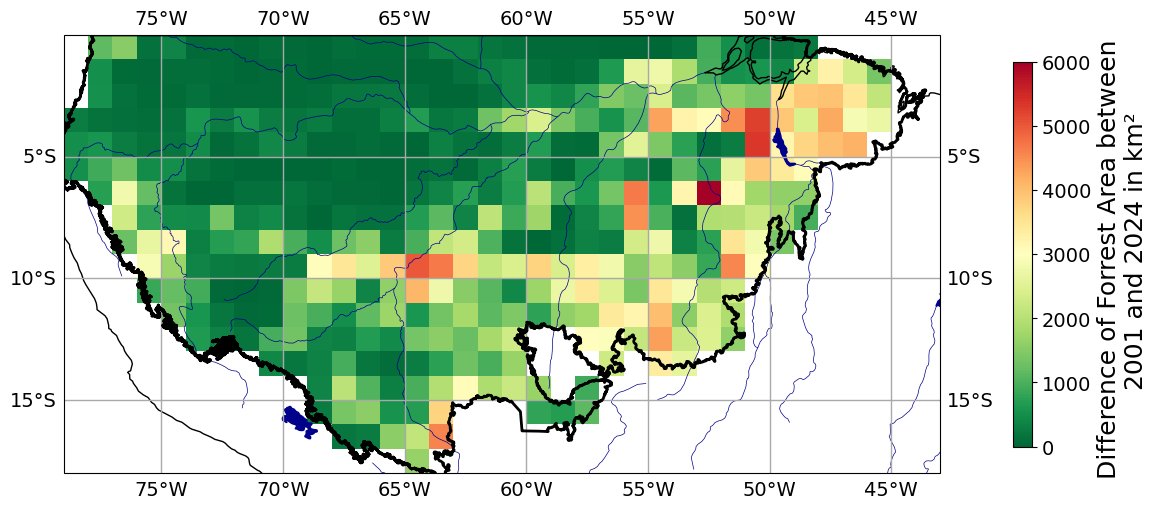

max pixel count: 7767738.0
-----------------------------------------------------------
Overall cutdown Area: 489599.62189314154 km²
Mean: 1174.099812693385 km² per pixel
Median: 675.4543438182989 km² per pixel
Max: 5977.509326321507 km²
<xarray.DataArray 'Difference' (lat: 1, lon: 1)> Size: 8B
array([[7767738.]])
Coordinates:
  * lat          (lat) float64 8B -6.5
  * lon          (lon) float64 8B -52.5
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    LAYER_TYPE:     athematic
    long_name:      Layer_1
_______________________________________________
<xarray.DataArray (lat: 1, lon: 1)> Size: 8B
array([[0.48548362]])
Coordinates:
  * lat          (lat) float64 8B -6.5
  * lon          (lon) float64 8B -52.5
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    LAYER_TYPE:     athematic
    long_name:  

In [54]:
#Generate Forrest Difference Plot & compute Areas of interest

count1 = float(ds_Fo_diff['Difference'].notnull().sum())
cdDmax=float(ds_Fo_diff['Difference'].max())
#--------------------------------------------------------------------------------------------------------------
cda2=float(ds_Fo_diff['Area2'].sum())
cdaa2=float(ds_Fo_diff['Area2'].mean())
cdam2=float(ds_Fo_diff['Area2'].median())
cdamax2=float(ds_Fo_diff['Area2'].max())
rel_Area=(ds_Fo_diff['Area2']/ds_Fo_diff['Area'])
indef=float(ds_Fo_diff['Area2'].sel(lat=-0.5, lon=-54.5))
#--------------------------------------------------------------------------------------------------------------
max_coords  = ds_Fo_diff['Difference'].where(ds_Fo_diff['Difference'] == ds_Fo_diff['Difference'].max(), drop=True)
ramax_coords= rel_Area.where(rel_Area == rel_Area.max(), drop=True)
#--------------------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

dp=ds_Fo_diff['Area2'].plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlGn_r',
    vmin=0, vmax=6000, cbar_kwargs={'pad': 0.065, 'shrink': 0.5}
)

ax.add_geometries(
    amazon_south.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=2,
    linestyle='---',
    zorder=5
)

#dp.colorbar.set_label('Difference of Forrest states between \n 2001 and 2024 (pixel count)', fontsize=SG)
dp.colorbar.set_label('Difference of Forrest Area between \n 2001 and 2024 in km²', fontsize=SG)
dp.colorbar.ax.tick_params(labelsize=SG-4)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=1)
#ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, color='darkblue')
ax.add_feature(cfeature.LAKES, linewidth=1, color='darkblue')
#ax.add_feature(cfeature.OCEAN, linewidth=1,zorder=2, color='darkblue')

gl = ax.gridlines(draw_labels=True, linewidth=1, color='darkgrey')
gl.xlocator = mticker.FixedLocator(range(-90, -39, 5))
gl.ylocator = mticker.FixedLocator(range(-30, 11, 5))
gl.xlabel_style = {'size': SG-4}
gl.ylabel_style = {'size': SG-4}


ax.set_title(None)
plt.tight_layout()
plt.savefig('/home/oscholz/plots/forest/difference.png')
plt.show()

print(f'max pixel count: {cdDmax}')

print('-----------------------------------------------------------')

print(f'Overall cutdown Area: {cda2} km²')
print(f'Mean: {cdaa2} km² per pixel')
print(f'Median: {cdam2} km² per pixel')
print(f'Max: {cdamax2} km²')
print(max_coords)
#print((f'defore in 0/55:{indef}'))
print('_______________________________________________')
print(ramax_coords)

# Modis Datensatz

In [35]:
# ──  Bivariate colour matrix (3×4) for bivariate map plots

bivar_colors = [
    "lightblue",   # DoD low,  Trend stark neg
    "lightcyan",   # DoD low,  Trend schwach neg
    "lightyellow", # DoD low,  Trend schwach pos
    "yellow",      # DoD low,  Trend stark pos
    "blue",        # DoD mid,  Trend stark neg
    "cornflowerblue", # DoD mid, Trend schwach neg
    "orange",      # DoD mid,  Trend schwach pos
    "darkorange",  # DoD mid,  Trend stark pos
    "darkblue",    # DoD high, Trend stark neg
    "purple",      # DoD high, Trend schwach neg
    "tomato",      # DoD high, Trend schwach pos
    "red",         # DoD high, Trend stark pos
]
cmap_bivar = ListedColormap(bivar_colors)

In [60]:
#All functions for generating plots and compute trends

def Diff_plot(dataset, start, end, colormap='RdBu_r', amz_mask=amz_mask, SG=SG):
    '''
    ---generates plots depicting the difference of the chosen variable between dry and wet season---

    dataset:  choose between 'COT_liq.nc' , 'CMF_low.nc', 'CPS_liq.nc' or 'CWP_liq.nc'
    start:    starting date, shall be date as string 'yyyy-mm-dd'
    end:      end date,      shall be date as string 'yyyy-mm-dd'
    colormap: prefered type of colorscale for map plot, default=RdBu_r
    amz_maks: select geogrphical mask, default=amz_mask
    SG:       fontsize
    '''
    
    if dataset=='COT_liq.nc':
        name='cot_liq'
        header='Cloud Optical Thickness (liquid clouds)' 
        ext=6
        dim=''
    elif dataset=='CMF_low.nc':
        name='cmf_low'
        header='Cloud Mask Fraction (low clouds)'
        ext=0.3
        dim=''
    elif dataset=='CPS_liq.nc':
        name='cps_liq'
        header='Cloud Effective Radius (liquid clouds)'
        dim=' [µm]'
        ext=3
    elif dataset=='CWP_liq.nc':
        name='cwp_liq'
        header='Cloud Water Path (liquid clouds)'      
        dim=' [g/m²]'
        ext=60
        
    sy = start[:4]
    ey = end[:4]
    modis=xr.open_dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/merged/'+dataset)
    modis_dry = modis.sel(time=modis.time.dt.month.isin([7,8,9])).sel(time=slice(start, end))
    modis_wet = modis.sel(time=~modis.time.dt.month.isin([7,8,9])).sel(time=slice(start, end))

    modis_dry['mean_avg']=modis_dry['Mean'].mean(dim='time', skipna=True).transpose("latitude", "longitude")
    modis_wet['mean_avg']=modis_wet['Mean'].mean(dim='time', skipna=True).transpose("latitude", "longitude")

    modis['diff']=modis_dry['mean_avg']-modis_wet['mean_avg']
    amz_mask=amz_mask.rename({
    "lon": "longitude",
    "lat": "latitude"
    })
    modis['mask']=amz_mask
    modis['diff']=modis['diff'].where(modis['mask']==True)
    
    fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": ccrs.PlateCarree()})
    pic= modis['diff'].plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=colormap,
        vmin=-ext,   
        vmax=ext, 
        cbar_kwargs={'pad': 0.065, 'shrink': 0.5}
    )
    pic.colorbar.ax.tick_params(labelsize=(SG-2))
    ax.add_geometries(
    amazon_south.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    zorder=5   # make sure it's drawn on top
    )
    pic.colorbar.set_label(f'seasonal difference {dim}', fontsize=SG)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True)
    gl.xlocator = mticker.FixedLocator(range(-90, -39, 5))
    gl.ylocator = mticker.FixedLocator(range(-30, 11, 5))
    gl.xlabel_style = {'size': SG-2}
    gl.ylabel_style = {'size': SG-2}

    ax.set_title(None)
    #ax.set_title(f"Seasonal difference of mean {header} \n dry-wet {sy}–{ey}", fontsize=13)
    savepath=f'/home/oscholz/plots/means/diffs/diff_{name}_{sy}_{ey}.png'
    plt.savefig(savepath, dpi=300, bbox_inches="tight", pad_inches=0.05)
    plt.tight_layout()
    plt.show()


#------------------------------------------------------------------------------------------------------------------------------------------#
#------------------------------------------------------------------------------------------------------------------------------------------#
#------------------------------------------------------------------------------------------------------------------------------------------#


def plot_map(Data, col_min, col_max, colormap="RdBu_r", SG=SG, ax=None, sig_data=None, typ=None, sig=None, sy=None, ey=None, season=None, data=None, header=None, folder=None, dim=None, amz_mask=amz_mask):
    '''
    ---generates plots depicting means, trends or p-values of trends --- plot_map() is part of analyze_modis and comi_tnd(), therefore gets its variables from there

    Data:     data that shall be plotted
    col_min:  minimal value, that shall be plotted
    col_max:  maximum value, that shall be plotted
    sig_data: p-value dataset if significance of trend shall be checked
    typ:      choose between mean_avg   (if climatological mean shall be plotted)
                             trend_Mean (if trends shall be plotted)
    sy:       start year
    ey:       end year
    dim:      dimension of variable
    '''
    
    standalone = ax is None
    amz_mask=amz_mask.rename({
    "lon": "longitude",
    "lat": "latitude"
    })
    Data['mask']=amz_mask
    sig_data['mask']=amz_mask
    Data=Data.where(Data['mask']==True)
    sig_data=sig_data.where(sig_data['mask']==True)
    
    was=" ".join(header.split()[:3])
    if sig:
        label=f'trend (per decade) {dim}'
        name='trend'
    else:
        label='p-value'
        name='pval'
 
    if typ=='mean_avg':
        label=f'mean {was} {dim}'
        name='clim_Mean'
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={"projection": ccrs.PlateCarree()})
    
    pic= (Data).plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=colormap,
        vmin=col_min,   
        vmax=col_max,
        add_colorbar=False
    )

                                
    if sig :
    # Non-significant areas hatched (p > 0.05)
        sig_mask = sig_data > 0.05
        ax.contourf(
            Data.longitude, Data.latitude,
            sig_mask.values,
            levels=[0.5, 1.5],
            hatches=["..."],
            colors="none",
            transform=ccrs.PlateCarree()
        )
    
    ax.add_geometries(
    amazon_south.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    zorder=5   # make sure it's drawn on top
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True)
    gl.xlocator = mticker.FixedLocator(range(-90, -39, 5))
    gl.ylocator = mticker.FixedLocator(range(-30, 11, 5))
    gl.xlabel_style = {'size': SG-2}
    gl.ylabel_style = {'size': SG-2}
    
    if sy=='2002' and ey=='2024':
        f2='/'
    else:
        f2='/var_years/'
    
    if typ =='mean_avg':
        folder='means'

    if standalone:

        cbar2 = fig.colorbar(
            pic, ax=ax, orientation='vertical', shrink=0.5, pad= 0.065,
        )
        cbar2.set_label(f'Trend {dim} per decade', fontsize=SG)
        pic.colorbar.ax.tick_params(labelsize=(SG-2))
        
        savepath=f'/home/oscholz/plots/{folder}{f2}{name}_{data}_{sy}_{ey}.png'
        plt.savefig(savepath, dpi=300, bbox_inches="tight", pad_inches=0.05)
        plt.tight_layout()
        plt.show()

    else:
        return ax, pic

#---------------------------------------------------------------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------------------------------------------------------------

def trends (Dataset):
    '''
    ---compute cloud property trend---
    This function was entirely generated by Claude - Sonet 5
    '''
    time_num = (Dataset.time - Dataset.time[0]).dt.days.values
    
    def linear_trend_with_pvalue(y):
        mask = ~np.isnan(y)
        if mask.sum() < 2:
            return np.nan, np.nan
        slope, _, _, pvalue, _ = stats.linregress(time_num[mask], y[mask])
        return slope, pvalue,
        
    # Slope und p-Wert berechnen
    slope, pvalue= xr.apply_ufunc(
        linear_trend_with_pvalue,
        Dataset["Mean"],
        input_core_dims=[["time"]],
        output_core_dims=[[], []],
        vectorize=True,
        output_dtypes=[float, float]
    )
    
    trend_modis = xr.Dataset({
        "trend_Mean": slope.transpose("latitude", "longitude"),
        "pvalue":     pvalue.transpose("latitude", "longitude")
        #'intercept':  inter.transpose("latitude", "longitude")
    })
    trend_modis['trend_Mean']=trend_modis['trend_Mean']*365*10
    return trend_modis
    
#---------------------------------------------------------------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------------------------------------------------------------

def bivariate_maps(trend_sig, sy, ey, cmap_bivar=cmap_bivar, data=None, header=None, folder=None, SG=SG, ax=None):
    '''
    ---plotting bivariate maps, combining deforestation and cloud property trends--- is part of analyze_modis() and combi_biv()

    trend_sig:    cloud property trend dataset, that shall be plotted - contains only significant trends
    sy,ey:        start year, end year
    cmap_bivar:   bivariate colormap, default=defined above
    '''
    
    standalone = ax is None
    fodif_vals = ds_Fo_diff["Area2"].squeeze().values
    trend_vals = trend_sig['trend_Mean'].squeeze().values 
        
    # ── classification ─────────────────────────────────────────────────────────
    both_valid_fo = ~np.isnan(fodif_vals) & ~np.isnan(trend_vals)
    fodif_t = np.nanpercentile(fodif_vals[both_valid_fo], [33, 66])
    
    # Trend: 4 classes with 0 as natürlicher threshold
    neg_vals = trend_vals[both_valid_fo & (trend_vals < 0)]
    pos_vals = trend_vals[both_valid_fo & (trend_vals > 0)]
    trend_t = [np.median(neg_vals), 0, np.median(pos_vals)]
    # → 0: stark neg | 1: schwach neg | 2: schwach pos | 3: stark pos
    
    def classify_deforestation(arr, thresholds):
        out = np.full(arr.shape, np.nan)
        out[arr <= thresholds[0]] = 0
        out[(arr > thresholds[0]) & (arr <= thresholds[1])] = 1
        out[arr > thresholds[1]] = 2
        return out
        
    def classify_trend(arr, thresholds):
        out = np.full(arr.shape, np.nan)
        out[arr <= thresholds[0]] = 0
        out[(arr > thresholds[0]) & (arr <= thresholds[1])] = 1
        out[(arr > thresholds[1]) & (arr <= thresholds[2])] = 2
        out[arr > thresholds[2]] = 3
        return out
    
    trend_class = classify_trend(trend_vals, trend_t)
    dof_class = classify_deforestation(fodif_vals, fodif_t)
    
    # combined Index 0–11 (3 DoD × 4 Trend)
    combo_fo = np.full(fodif_vals.shape, np.nan)
    combo_fo[both_valid_fo] = dof_class[both_valid_fo] * 4 + trend_class[both_valid_fo]
    
    #plot map with forrest difference ----------------------------------------------------------------------------------------------------------     
    if ax is None:
        fig, ax = plt.subplots(
            figsize=(12, 9),
            subplot_kw={"projection": ccrs.PlateCarree()}
        )
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.RIVERS,   linewidth=0.5)
    
    #Bivariate chart--------------------------------------------------------------------------------------------------------
    
    im = ax.pcolormesh(
        x_mids, y_mids, combo_fo,
        cmap=cmap_bivar, vmin=0, vmax=11,
        transform=ccrs.PlateCarree(), zorder=2
    )
    
    # Forest BG----------------------------------------------------------------------------------------------------------------
    nan_mask = np.where(np.isnan(combo_fo), ds_Fo_diff['Area2'], np.nan)
    im = ax.pcolormesh(
        x_mids, y_mids, nan_mask,
        cmap='Greys', vmin=0, vmax=6000,
        transform=ccrs.PlateCarree(), zorder=1
    )

    #Amazonas Gebiet-----------------------------------------------------------------------------------------------------------
    
    ax.add_geometries(
        amazon_south.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    gl = ax.gridlines(draw_labels=True)
    gl.xlocator = mticker.FixedLocator(range(-90, -39, 5))
    gl.ylocator = mticker.FixedLocator(range(-30, 11, 5))
    gl.xlabel_style = {'size': SG-2}
    gl.ylabel_style = {'size': SG-2}

    #legende & Beschreibung------------------------------------------------------------------------------------------------------------
    if standalone:
        # ── Bivariate legend ────────────────────────────────────────────────────
        legend_ax = fig.add_axes([0.685, 0.3, 0.22, 0.16])
    
        # White box directly behind legend_ax, slightly padded to cover map edge + "15°S"
        fig.patches.append(plt.Rectangle(
            (0.63, 0.25), 0.20, 0.21,   # (left, bottom), width, height — figure coords
            transform=fig.transFigure,
            facecolor="white", edgecolor="None",
            zorder=4
        ))
        legend_ax.set_zorder(5)   # keep legend above the white box
    
        legend_grid = np.arange(12).reshape(3, 4)
        legend_ax.imshow(legend_grid, cmap=cmap_bivar, vmin=0, vmax=11,
                         origin="lower", aspect="auto")
        legend_ax.set_xticks([0, 1, 2, 3])
        legend_ax.set_xticklabels(["strong \n negative", "negative", "positive", "strong \n positive"], fontsize=SG-7)
        legend_ax.set_yticks([0, 1, 2])
        legend_ax.set_yticklabels(["low", "mid", "high",], fontsize=SG-7)
        legend_ax.tick_params(length=0)
        legend_ax.text(
            -0.2, 0.5, "Deforestation",
            transform=legend_ax.transAxes,
            fontsize=SG-4, va="center", ha="center",
            rotation=90
        )
        legend_ax.text(
            0.5, -0.31, "Trend",
            transform=legend_ax.transAxes,
            fontsize=SG-4, va="center", ha="center"
        )
    
        #---Black white Colorbar
        cbar = fig.colorbar(
            im, ax=ax, orientation='vertical',
            pad=0.05, shrink=0.3, anchor=(0.3, 0.68)   
        )
        cbar.set_label('$A_{loss}$ [km²]', fontsize=SG)
        im.colorbar.ax.tick_params(labelsize=(SG-2))

        #plt.tight_layout()
        savepath2=f'/home/oscholz/plots/{folder}/bivariate_map_area_{data}.png'
        plt.savefig(savepath2, dpi=300, bbox_inches="tight", pad_inches=0.05)
        plt.show()
    else:
        return ax, im
#---------------------------------------------------------------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------------------------------------------------------------

def cor(trend_set, for_set,header=None, folder=None,data=None, dim=None):

    '''
    ---computes correlation between deforestation and cloud property trend -----------
    '''
    region_mask = regionmask.mask_geopandas(amazon_south, x_mids, y_mids)
    amz_mask = ~np.isnan(region_mask.values)   # True inside polygon, False outside
    
    trend_vals_amz = trend_set[amz_mask]
    dof_vals_amz   = for_set[amz_mask]
    both_valid_amz2 = ~np.isnan(dof_vals_amz) & ~np.isnan(trend_vals_amz)
    dof_flat    = dof_vals_amz[both_valid_amz2].flatten()
    trend_flat2 = trend_vals_amz[both_valid_amz2].flatten()
    print(f"Number of points (dof): {len(dof_flat)}")
    slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(dof_flat, trend_flat2)
    
    #── Plot: Fo_diff × Trend ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(dof_flat, trend_flat2, alpha=0.6, edgecolors="k", linewidths=0.3, s=40, color="steelblue")
    x_line2 = np.linspace(dof_flat.min(), dof_flat.max(), 100)
    y_line2 = slope2 * x_line2 + intercept2
    ax.plot(x_line2, y_line2, color="red", linewidth=2,
            label=f"Slope: {slope2:}\n$R^2$ = {r_value2**2:.3f}\n R = {r_value2}\np = {p_value2:.4f}")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Forest Difference (pixel count)", fontsize=12)
    ax.set_ylabel(f"Trend of {header} \n (per decade)", fontsize=12)
    ax.set_title(f"Forest difference (pixel count) & {header} trend (low clouds)\n"
                 "Amazon south of equator (RAISG boundary), only significant trends (p < 0.05)", fontsize=13)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(f'/home/oscholz/plots/{folder}/cor/scatter_pixel_{data}.png', dpi=300, bbox_inches="tight", pad_inches=0.05)
    plt.show()



#---------------------------------------------------------------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------------------------------------------------------------

def analyze_modis(dataset, typ, season , SG=SG, start='2002-07-04', end  ='2026-03-11',col_min=None, col_max=None, colormap="RdBu_r",colormap_mean='turbo', only_sig=True, plots=True, biv=True, correlation=False, analyse=False, amz_mask=amz_mask, lonal=-52.5, latal=-6.5, slc=False, lon_W=-79, lon_E=-43, lat_S=-18, lat_N=0):
    '''
    ---Heart of Analysis - Function bringing everything together---------Type of output can be determined -----------
    
    dataset choose between (or create a new file with concat.ipynb and choose that one): 
         'COT_liq.nc'        (Cloud Optical Thickness of liqiud clouds)
         'CMF_low.nc'        (Cloud Mask Fraction of low clouds) 
         'CPS_liq.nc'        (Cloud Particle Size of liquid cloud)
         'CWP_liq.nc'
    
    typ choose between:
        'mean_avg'   
        'trend_Mean'
        'pvalue'
        
    season choose between: 
        'off' for a total annual view       or
        'dry' for dry season analysis         or
        'wet' for wet season analysis

    SG:            fontsize
    col_min:       minimum value, that shall be plotted
    col_max:       maximum value, that shall be plotted
    colormap:      colormap for plots of trends, default="RdBu_r"
    colormap_mean: colormap for plots of climatological mean, default=turbo
    only_sig:      plots only significant trends (rest is hatched in tren plots, neglected in bivariate plots)
    plots:         Boolean, shall the function generate plots? 
    biv:           Boolean, shall the function generate bivariate map plots?
    correlation:   Boolean, shall the function compute correaltions and plot them as scatterplots
    analyse:       Boolean, shall the function compute and print mean, median of trends etc
    lonal, latal:  longitude and latitude of a certain pixel, that shall be exmined, default on pixel with strongest deforestation 
    slc:           Bolean, if True, Analysis is performed for the area defined by
                   lon_W - most western longitude 
                   lon_E - most eastern longitude
                   lat_S - most southern latitude
                   lat_N - most northern latitude
    '''
    
    signif=False if typ=='pvalue' or typ=='mean_avg' else True
    modis=xr.open_dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/merged/'+dataset)
    modis=modis.transpose("time","latitude", "longitude")

    
    sy = start[:4]
    ey = end[:4]

    dim=' '
    cmin=None
    cmax=None
    
    if dataset=='COT_liq.nc':
        folder='cot_liq'
        data=folder
        header='Cloud Optical Thickness' 
        cmin=-1.25
        cmax=1.25
    elif dataset=='CMF_low.nc':
        folder='cmf_low'
        data=folder
        header='Cloud Mask Fraction of low clouds'
        cmin=-0.05
        cmax=0.05
    elif dataset=='CPS_liq.nc':
        folder='cps_liq'
        data=folder
        header='Cloud Effective Radius'
        dim=' [µm] '
        cmin=-1
        cmax=1
    elif dataset=='CWP_liq.nc':
        folder='cwp_liq'
        data=folder
        header='Liquid Water Path'      
        dim=' [g/m²] '
        cmin=-12
        cmax=12
        
    elif dataset=='COT_liq_PCL.nc':
        folder='cot_liq_pcl'
        data=folder
        header='Cloud Optical Thickness of liquid clouds (partly cloudy scene)' 
  
    elif dataset=='CPS_liq_PCL.nc':
        folder='cps_liq_pcl'
        data=folder
        header='Effective Radius of liquid clouds (partly cloudy scene)'
        dim=' [µm] '
    elif dataset=='CWP_liq_PCL.nc':
        folder='cwp_liq_pcl'
        data=folder
        header='Cloud Water Path (liquid clouds, partly cloudy scene)'
        dim=' [g/m²] '

    modis['mean_avg_overall']=modis['Mean'].mean(dim='time', skipna=True)
    
    amz_mask = ~np.isnan(region_mask)
    amz_mask=amz_mask.rename({
    "lon": "longitude",
    "lat": "latitude"
    })
    modis['mask']=amz_mask
    modis['masked_data']=modis['mean_avg_overall'].where(modis['mask']==True)
    ovrmin=float(modis['masked_data'].min())
    ovrmax=float(modis['masked_data'].max())
        
    if season=='dry':
        modis = modis.sel(time=modis.time.dt.month.isin([7,8,9]))
        header=header+' in dry season'
        data=folder+'_dry'
    elif season=='wet':
        modis = modis.sel(time=~modis.time.dt.month.isin([7,8,9]))
        header=header+' in wet season'
        data=folder+'_wet'
    else:
        pass

    modis=modis.sel(time=slice(start, end))
    modis=modis
    modis['mean_avg']=modis['Mean'].mean(dim='time', skipna=True).transpose("latitude", "longitude")

    trend_modis=trends(modis)
    trend_sig = trend_modis.where(trend_modis['pvalue'] <= 0.05)
    #trend_vals=np.array(trend_sig['trend_Mean'])

    
    if typ=='mean_avg':
        data2=modis['mean_avg']
        colormap='turbo'
        if dataset=='CPS_liq.nc' or 'COT_liq.nc':
            cmin=ovrmin
            cmax=ovrmax
        elif dataset=='CMF_low.nc':
            cmin=0
            cmax=1
        else:
            cmin=0
            cmax=ovrmax
    elif typ=='pvalue':
        cmin=0
        cmax=0.1
        data2=trend_modis[typ]
    else:
        data2=trend_modis[typ]
    
    if plots:
        plot_map(data2, col_min=cmin, col_max=cmax, sig_data=trend_modis["pvalue"], colormap=colormap,typ=typ, sig=signif, sy=sy, ey=ey, season=season, data=data, header=header, folder=folder, dim=dim)
        if analyse:
            if typ == 'mean_avg':
                data2['mask']=amz_mask
                ad=data2.where(data2.mask==True)
                max_ad  =float(ad.max())
                min_ad  =float(ad.min())
                mean_ad =float(ad.mean())
                mid_ad  =float(ad.median())
    
                min_coords = ad.where(ad == ad.min(), drop=True)
                max_coords = ad.where(ad == ad.max(), drop=True)
                
                val_an= ad.sel(latitude=latal, longitude=lonal)
            else:
                trend_sig['mask']=amz_mask
                ad=trend_sig.where(trend_sig.mask==True)
                max_ad  =float(ad['trend_Mean'].max())
                min_ad  =float(ad['trend_Mean'].min())
                mean_ad =float(ad['trend_Mean'].mean())
                mid_ad  =float(ad['trend_Mean'].median())
    
                min_coords = ad['trend_Mean'].where(ad['trend_Mean'] == ad['trend_Mean'].min(), drop=True)
                max_coords = ad['trend_Mean'].where(ad['trend_Mean'] == ad['trend_Mean'].max(), drop=True)
                
                val_an= ad['trend_Mean'].sel(latitude=latal, longitude=lonal)
                
                if slc:
                    ad2=ad.sel(longitude=slice(lon_W,lon_E), latitude=slice(lat_S, lat_N))
                    print(ad2)
                    m2=float(ad2['trend_Mean'].mean(skipna=True))
                    med2=float(ad2['trend_Mean'].median(skipna=True))
            print(f'Max= {max_ad}')
            print(max_coords)
            print('-----------------------------------------------')
            print(f'Min= {min_ad}')
            print(min_coords)
            print('-----------------------------------------------')
            print(f'Mean= {mean_ad}')
            print('-----------------------------------------------')
            print(f'Median= {mid_ad}')
            print('-----------------------------------------------')
            print(f'Certain Pixel Value: {val_an}')
            if slc:
                print('-----------------------------------------------')
                print(f'mean east={m2}')
                print(f'mid east={med2}')
            
        
        if biv:
            bivariate_maps(trend_sig, sy=sy, ey=ey, data=data, header=header, folder=folder)
        if correlation:
            cor(trend_vals,fodif_vals,header=header, folder=folder, data=data,dim=dim)
    
    else:
        #avg_trend=float(trend_modis['trend_Mean'].mean())
        #return avg_trend
        return trend_sig, trend_modis, folder, header, dim, cmin, cmax

#---------------------------------------------------------------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------------------------------------------------------------
def combi_biv(setlist, sy=2002, ey=2024):
    '''
    ---3 plots of bivariate maps, 1 colormaplegend ---
    '''
    for nc in setlist:
        fig, axes = plt.subplots(3, 1, figsize=(9, 16), subplot_kw={"projection": ccrs.PlateCarree()})
    
        trend_sig1,_, folder1, header1, _,_,_ = analyze_modis(nc, 'trend_Mean', season = 'off', start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)
        bivariate_maps(trend_sig1,sy=sy, ey=ey, SG=SG, ax=axes[0], header=header1)
    
        trend_sig2,_, folder1, header2,_,_,_ = analyze_modis(nc, 'trend_Mean', season = 'dry', start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)
        bivariate_maps(trend_sig2,sy=sy, ey=ey, SG=SG, ax=axes[1], header=header2)
    
        trend_sig3,_, folder1, header3,_,_,_ = analyze_modis(nc, 'trend_Mean', season = 'wet', start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)
        _, im=bivariate_maps(trend_sig3,sy=sy, ey=ey, SG=SG, ax=axes[2], header=header3)
    
        #Bildunterschriften (Claude Sonet)
        headers = [header1, header2, header3]
        fig.subplots_adjust(hspace=0.4)
        for letter, ax, header in zip(string.ascii_lowercase, axes, headers):
            ax.text(
                0.5, -0.11, f"{letter}) Trend of {header} with deforestation",
                transform=ax.transAxes,
                fontsize=SG-2, va="top", ha="center"
            )
    
        # ── Bivariate legend ────────────────────────────────────────────────────
        legend_ax = fig.add_axes([0.15, 0.0, 0.3, 0.07]) #links, unten, breite. höhe
        legend_grid = np.arange(12).reshape(3, 4)
        legend_ax.imshow(legend_grid, cmap=cmap_bivar, vmin=0, vmax=11,
                         origin="lower", aspect="auto")
        legend_ax.set_xticks([0, 1, 2, 3])
        legend_ax.set_xticklabels(["strong \n negative", "negative", "positive", "strong \n positive"], fontsize=SG-7)
        legend_ax.set_yticks([0, 1, 2])
        legend_ax.set_yticklabels(["low", "mid", "high",], fontsize=SG-7)
        legend_ax.tick_params(length=0)
        legend_ax.text(
            -0.2, 0.5, "Deforestation",
            transform=legend_ax.transAxes,
            fontsize=SG-4, va="center", ha="center",
            rotation=90
        )
        legend_ax.text(
            0.5, -0.31, "Trend",
            transform=legend_ax.transAxes,
            fontsize=SG-4, va="center", ha="center"
        )
        #-----Forest BG-legend-1---------------------------------------------------------
    
        cbar_ax = fig.add_axes([0.48, 0.025, 0.45, 0.03])  # left, bottom, width, height
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
        cbar.set_label('$A_{loss}$ [km²]', fontsize=SG)
        cbar.ax.tick_params(labelsize=SG-2)
    
        
        if sy==2002 and ey==2024:
            savepath2=f'/home/oscholz/plots/{folder1}/trend_combimap{folder1}.png'
        else:
            savepath2=f'/home/oscholz/plots/{folder1}/trend_combimap{folder1}_{sy}_{ey}.png'
        plt.savefig(savepath2, dpi=300, bbox_inches="tight", pad_inches=0.05)
        plt.show()
        
#-------------------------------------------------------------------------------------------------------------------------------
#-------------------------------------------------------------------------------------------------------------------------------

def combi_tnd(setlist, sy=2002,ey=2024 ):
    '''
    ---3 trend maps, combined colormap(legend)---
    '''
    for nc in setlist:
        fig, axes = plt.subplots(3, 1, figsize=(9, 16), subplot_kw={"projection": ccrs.PlateCarree()})
    
        _ , trend1, folder1, header1, dim1, cmin1, cmax1 = analyze_modis(nc, 'trend_Mean', season = 'off', start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)
        _ , im = plot_map(trend1['trend_Mean'], col_min=cmin1, col_max=cmax1, ax=axes[0], sig_data=trend1['pvalue'] , sig=True, sy=sy, ey=ey, season='off', data=None, header=header1, folder=folder1, dim=dim1)
    
        _ , trend2, folder2, header2, dim2, cmin2, cmax2 = analyze_modis(nc, 'trend_Mean', season = 'dry', start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)
        plot_map(trend2['trend_Mean'], col_min=cmin2, col_max=cmax2,ax=axes[1], sig_data=trend2['pvalue'] , sig=True, sy=sy, ey=ey, season='dry', data=None, header=header2, folder=folder2, dim=dim2)
    
        _ , trend3, folder3, header3, dim3, cmin3, cmax3 = analyze_modis(nc, 'trend_Mean', season = 'wet', start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)
        plot_map(trend3['trend_Mean'], col_min=cmin3, col_max=cmax3,ax=axes[2], sig_data=trend3['pvalue'] , sig=True, sy=sy, ey=ey, season='wet', data=None, header=header3, folder=folder3, dim=dim3)
    
        #Bildunterschriften (Claude Sonet)
        headers = [header1, header2, header3]
        fig.subplots_adjust(hspace=0.4)
        for letter, ax, header in zip(string.ascii_lowercase, axes, headers):
            ax.text(
                0.5, -0.11, f"{letter}) Trend of {header}",
                transform=ax.transAxes,
                fontsize=SG-2, va="top", ha="center"
            )
    
        #-----Trend-Colorbar-Legende---------------------------------------------------------
    
        cbar_ax = fig.add_axes([0.115, 0.035, 0.8, 0.015])  # left, bottom, width, height
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
        cbar.set_label(f'Trend{dim3}per decade \n dotted, where trends are insignificant' , fontsize=SG)
        cbar.ax.tick_params(labelsize=SG-2)
    
        if sy==2002 and ey==2024:
            savepath2=f'/home/oscholz/plots/{folder1}/trend_combimap{folder1}.png'
        else:
            savepath2=f'/home/oscholz/plots/{folder1}/trend_combimap{folder1}_{sy}_{ey}.png'
        plt.savefig(savepath2, dpi=300, bbox_inches="tight", pad_inches=0.05)
        plt.show()

def onepix(dataset, nino, lat, lon, season='off'):
    '''
    --- plots time series of chosen variable at chosen pixel ---

    dataset: choose between 'COT_liq.nc' , 'CMF_low.nc', 'CPS_liq.nc' or 'CWP_liq.nc'
    nino:    ENSO data (MEI)
    lat:     latitude of pixel
    lon:     longitude of pixel
    season:  'off', 'dry', 'wet'
    '''
    op=xr.open_dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/merged/'+dataset)
    var=dataset[:3]
    if season=='dry':
        op = op.sel(time=op.time.dt.month.isin([7,8,9]))
        
    elif season=='wet':
        op = op.sel(time=~op.time.dt.month.isin([7,8,9]))
        
    op=op.transpose("time","latitude", "longitude")
    cell=op.sel(longitude=lon, latitude=lat)
    monMean= cell['Mean'].resample(time='1MS').mean()
    ciod=monMean.to_dataset(name='monMean')
    ciod['time'] = pd.to_datetime(ciod['time'].values).to_period('M')

#generated by Claude Sonet 5------------------------------------------------------------------
    
    start = ciod['time'].values.min().to_timestamp()
    iod_filtered = iod[pd.to_datetime(iod['date']) >= start]
    iod_indexed = iod_filtered.set_index(pd.to_datetime(iod_filtered['date']).dt.to_period('M'))
    ciod['MEI'] = ('time', iod_indexed['mei'].reindex(ciod['time'].values).values)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    times = ciod['time'].to_index().to_timestamp()
    months = times.month
    mei = ciod['MEI'].values
    cmap = plt.get_cmap('RdBu_r')
    norm = mcolors.TwoSlopeNorm(vmin=np.nanmin(mei), vcenter=0, vmax=np.nanmax(mei))
    colors = np.where(np.isin(months, [7, 8, 9]), 'red', 'blue')
    for i in range(len(times) - 1):
        if np.isnan(mei[i]):
            continue
        color = cmap(norm(mei[i]))
        ax.axvspan(times[i], times[i + 1], color=color, alpha=0.4)
    
        ax.scatter(times, ciod['monMean'].values, color='black', zorder=3)

    # Colorbar labeled with ENSO phases instead of raw MEI values
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, label='ENSO (MEI)')
    cbar.set_ticks([np.nanmin(mei), 0, np.nanmax(mei)])
    cbar.set_ticklabels(['La Niña', 'Neutral', 'El Niño'])
    
    plt.tight_layout()
    plt.savefig(f"plots/onepix_enso_{var}_{season}.png", dpi=150)
    plt.show()
    
#generated till this point---------------------------------------------------------------------------------------------

# Code Ausführen 

In [ ]:
onepix('CPS_liq.nc', iod, -5.5, -52.5,season='off')

In [ ]:
robustness('CMF_low.nc', 'dry')

In [ ]:
def robustness(nc, seasn):
    '''
    ---checks wether trends are robust regarding the temporal start and endpoints-----
    '''
    results = {}

    for sy in [2002]:#, 2003, 2004, 2005]:
        for ey in [2025]:#, 2024, 2023, 2022]:
            # key = (start_year, end_year), value = the result
            results[(sy, ey)] = analyze_modis(nc, 'trend_Mean', season=seasn ,start=f'{sy}-01-01', end=f'{ey}-12-31', plots=False)[1]
    

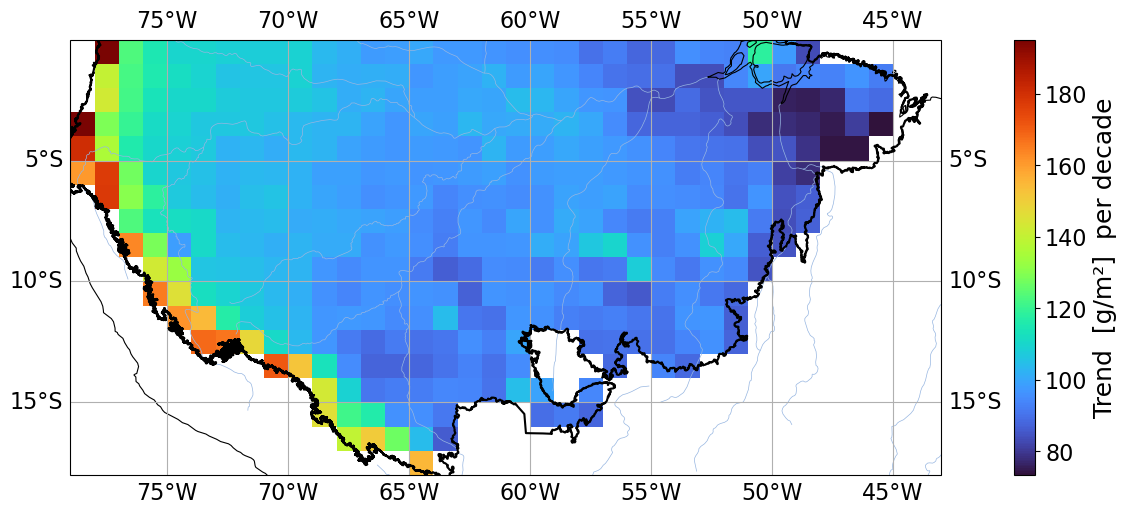

Max= 195.9910454854493
<xarray.DataArray 'mean_avg' (latitude: 1, longitude: 1)> Size: 8B
array([[195.99104549]])
Coordinates:
  * latitude   (latitude) float64 8B -0.5
  * longitude  (longitude) float64 8B -77.5
    mask       (latitude, longitude) bool 1B True
Attributes:
    title:    Cloud_Water_Path_Liquid: Mean
    units:    g/m^2
-----------------------------------------------
Min= 73.26483434564686
<xarray.DataArray 'mean_avg' (latitude: 1, longitude: 1)> Size: 8B
array([[73.26483435]])
Coordinates:
  * latitude   (latitude) float64 8B -3.5
  * longitude  (longitude) float64 8B -45.5
    mask       (latitude, longitude) bool 1B True
Attributes:
    title:    Cloud_Water_Path_Liquid: Mean
    units:    g/m^2
-----------------------------------------------
Mean= 101.47148986749228
-----------------------------------------------
Median= 97.49601339427392
-----------------------------------------------
Certain Pixel Value: <xarray.DataArray 'mean_avg' ()> Size: 8B
array(194.7460379

In [66]:
analyze_modis('CWP_liq.nc', 'mean_avg', season='off', start ='2002-01-01', latal=-3.5, lonal=-78.5, end ='2024-12-31',plots=True, analyse=True , biv=False, correlation=False, slc=False, lat_S=-9,lon_E=-60)

#### alle 3 seasons untereinander

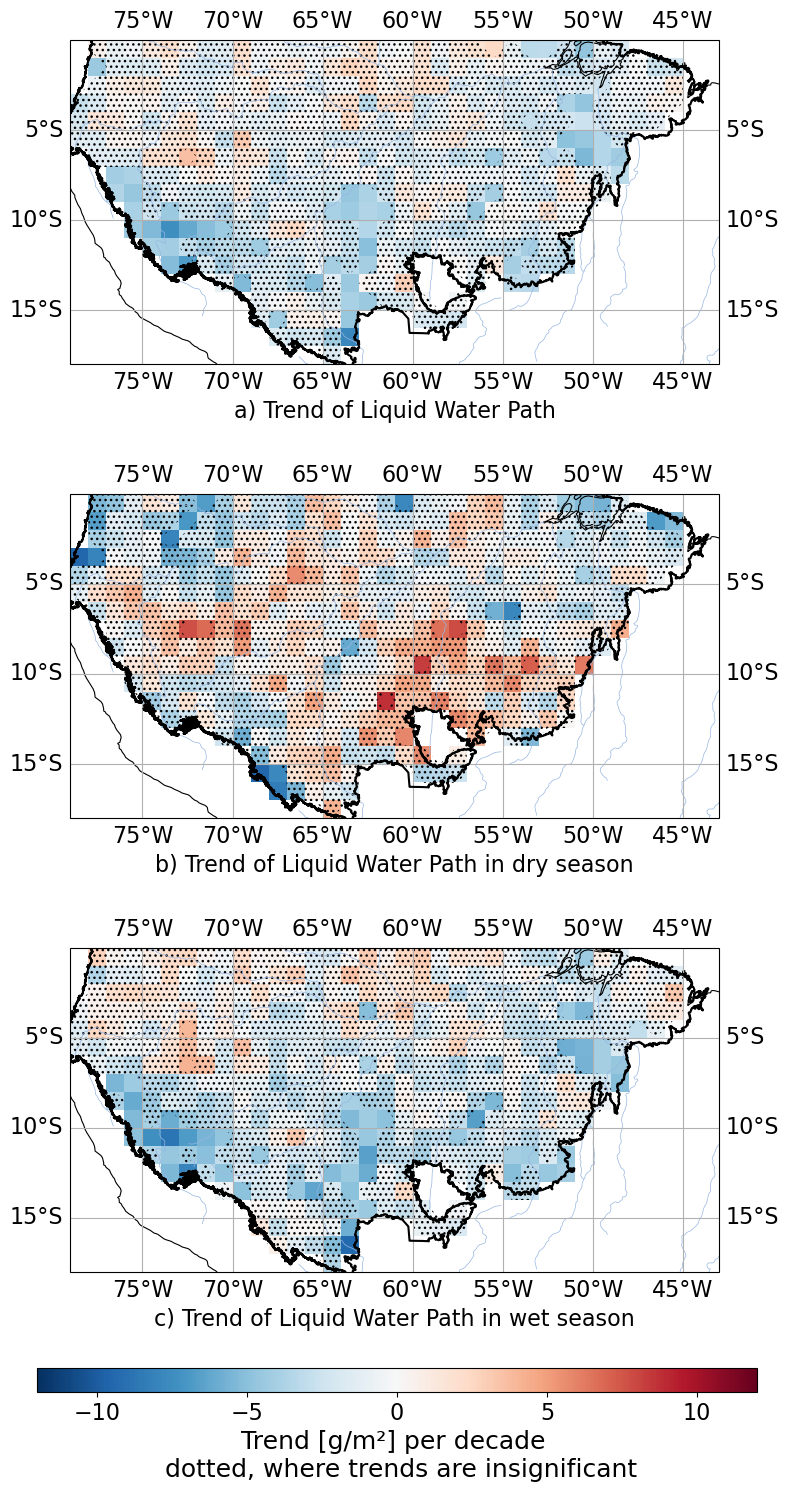

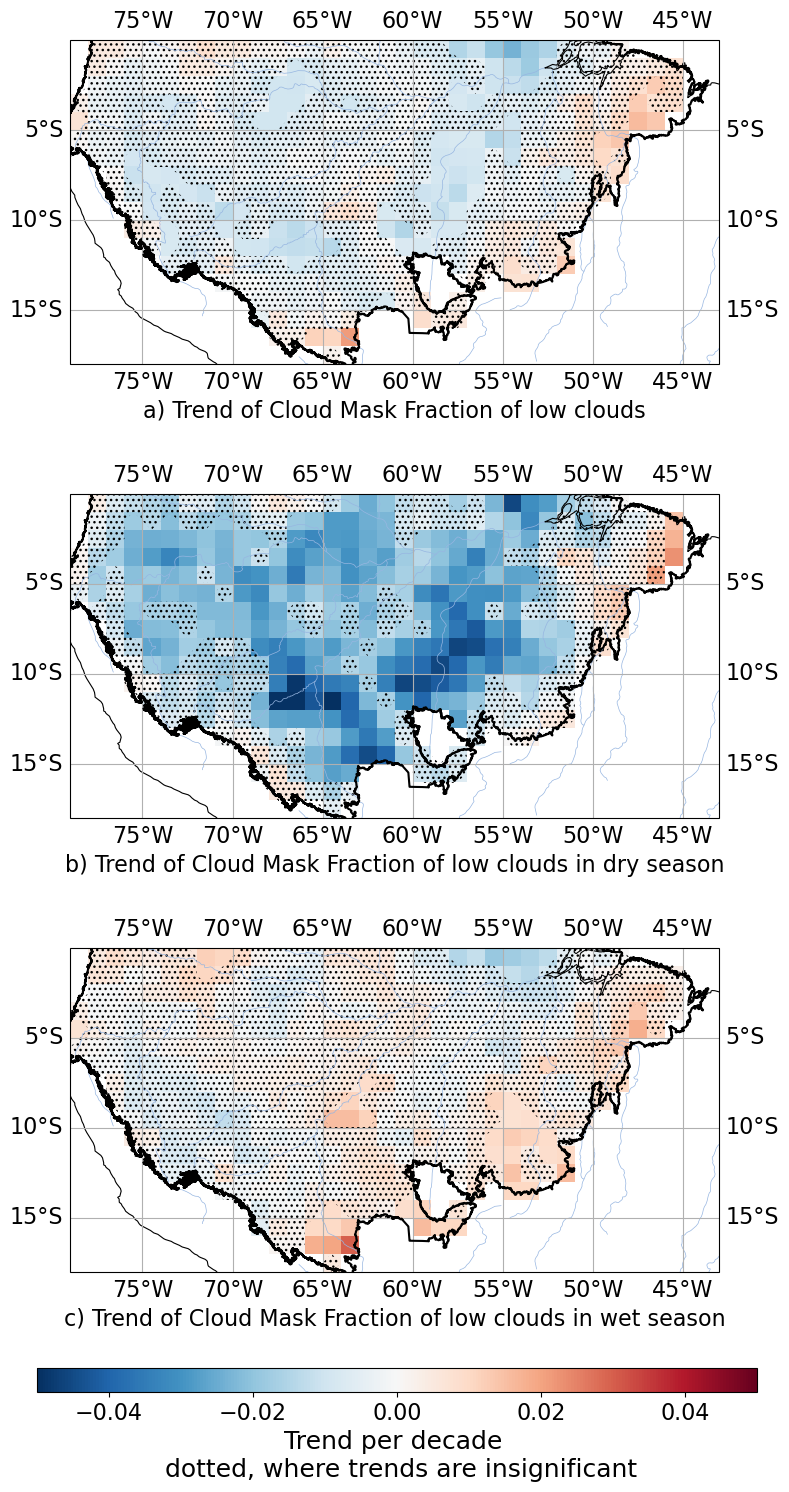

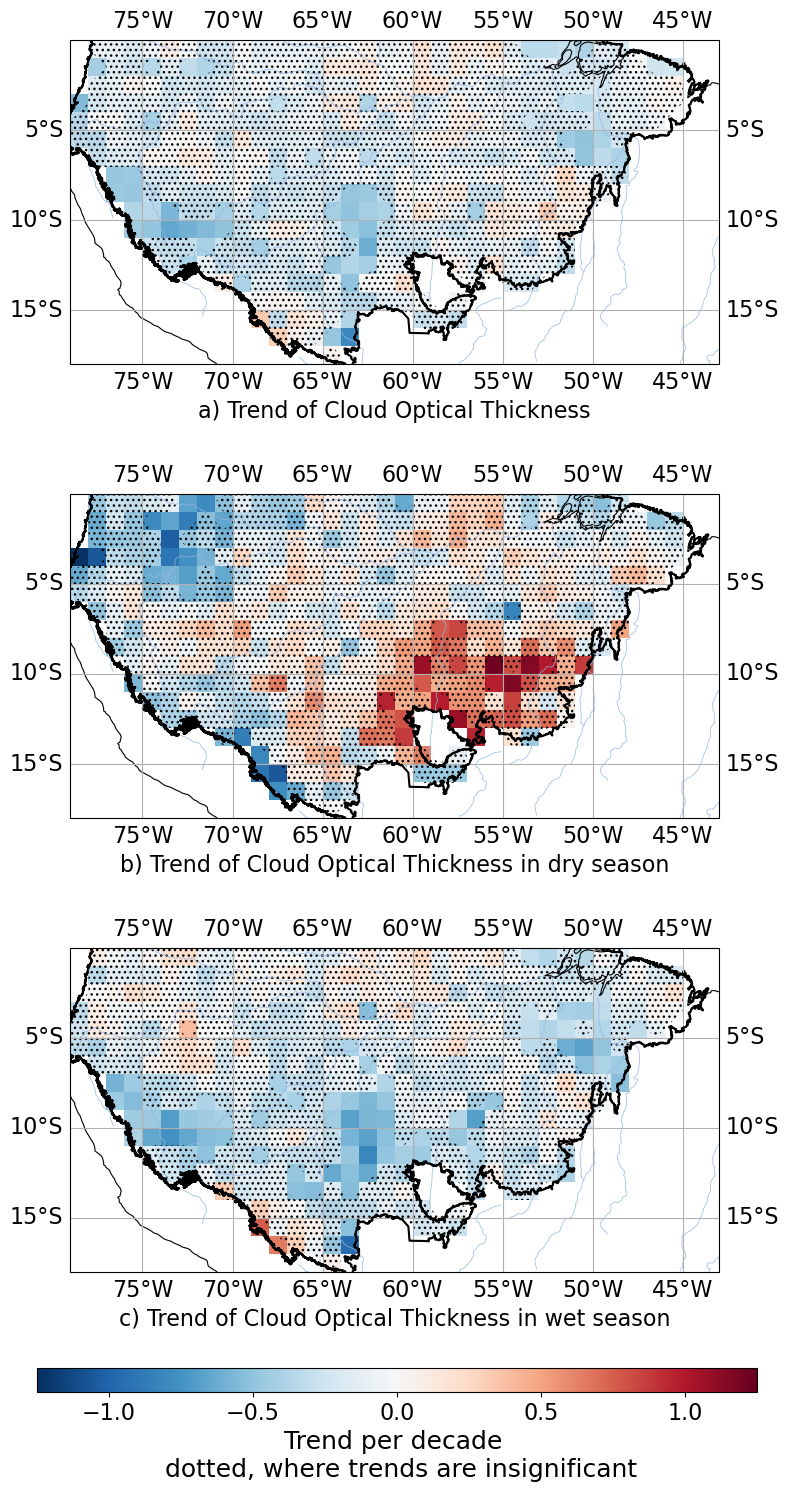

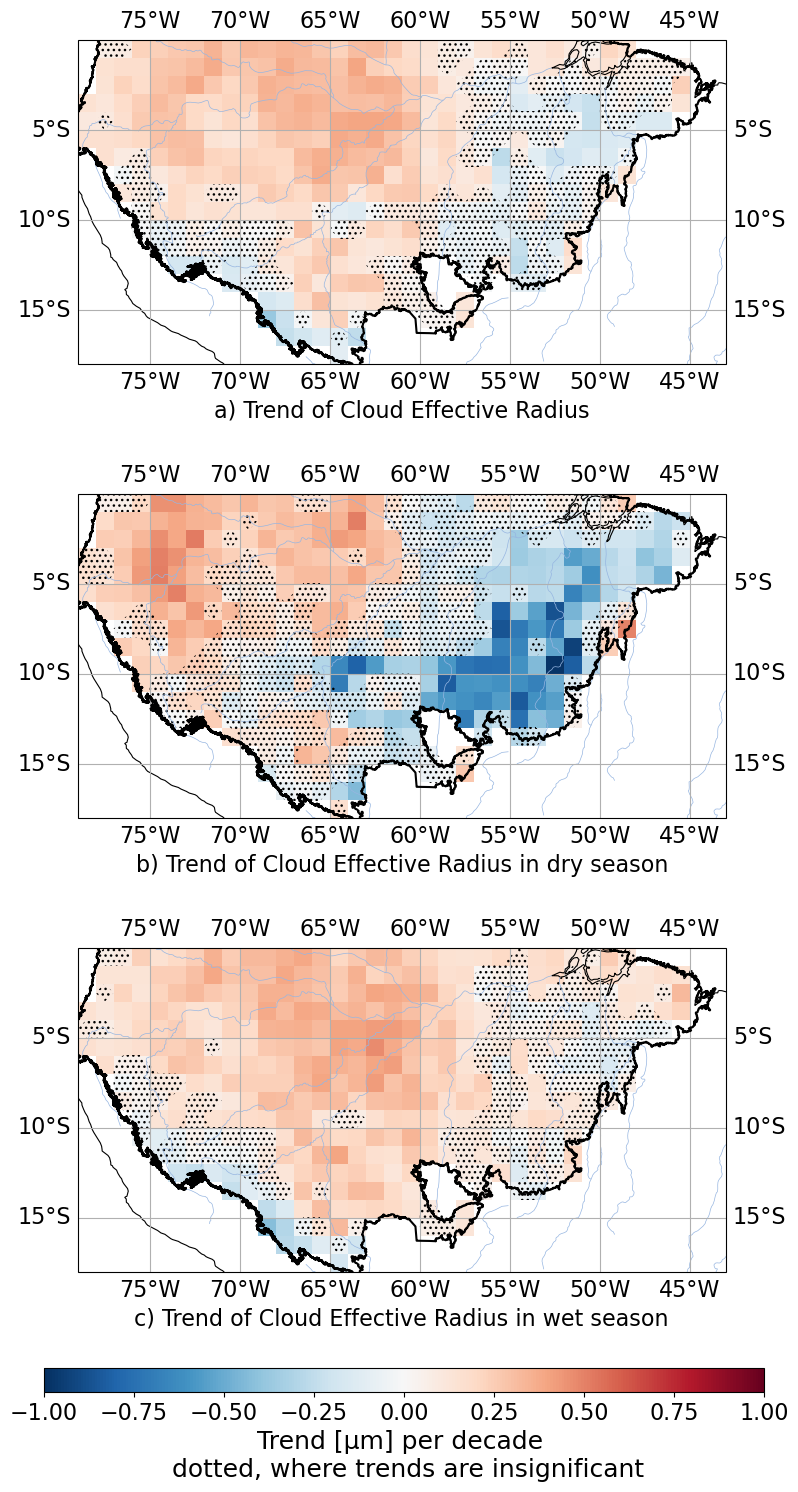

In [27]:
combi_tnd(sets, sy=2003, ey=2023 )

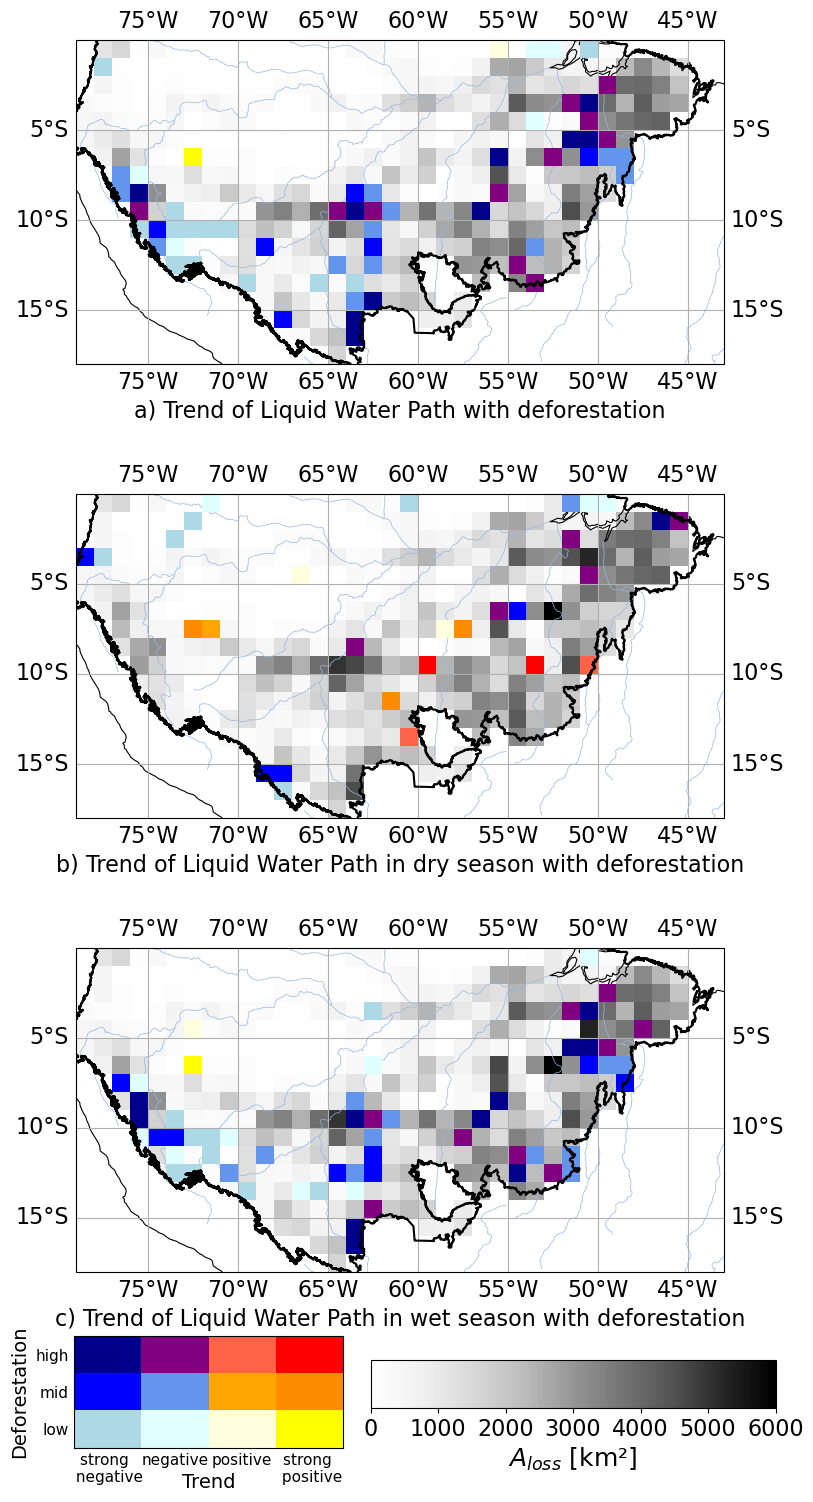

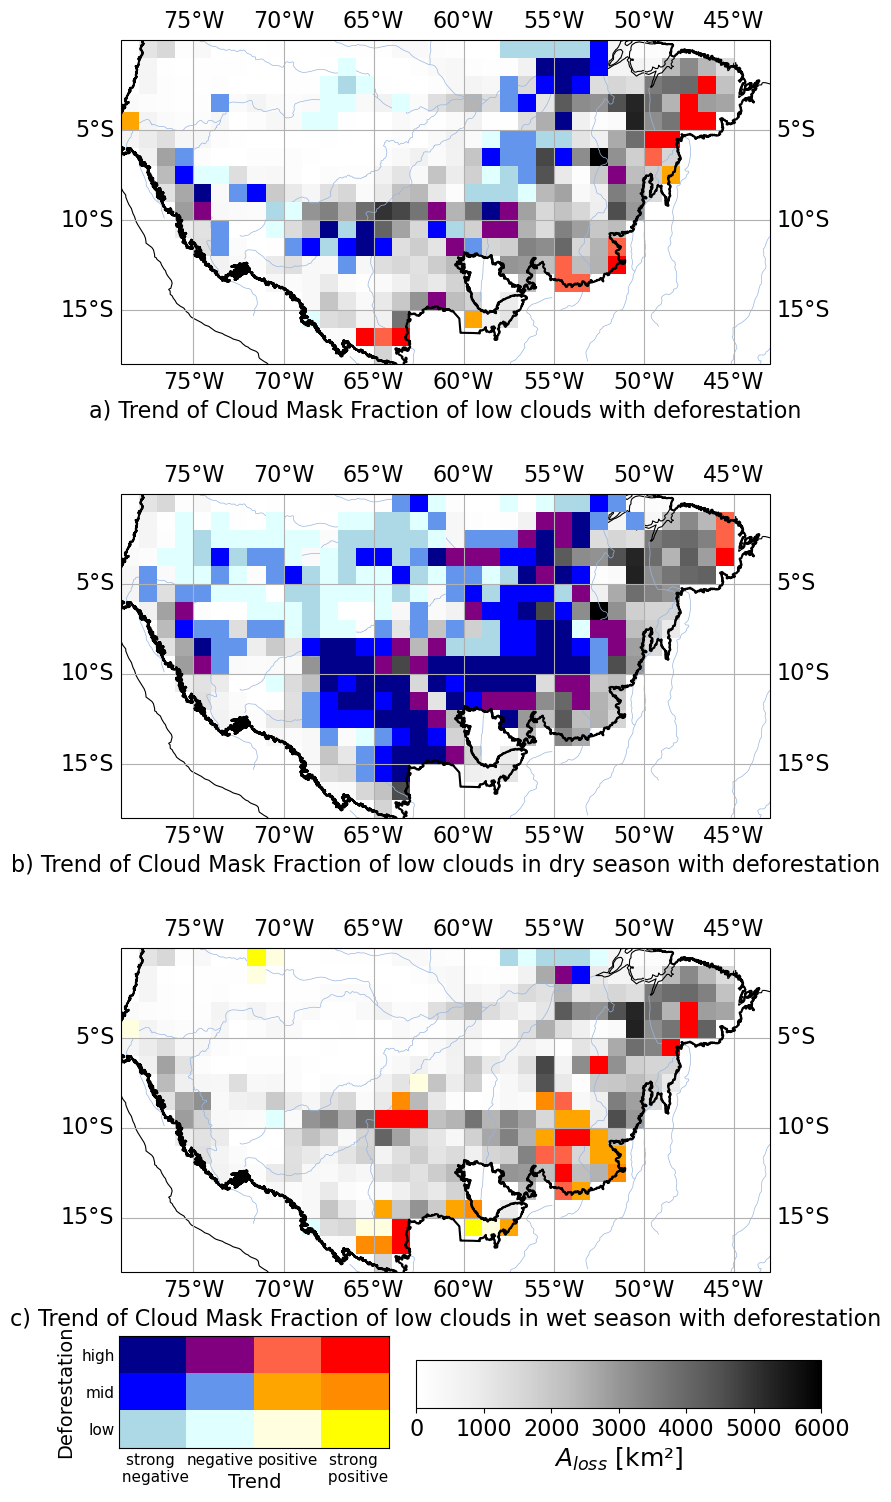

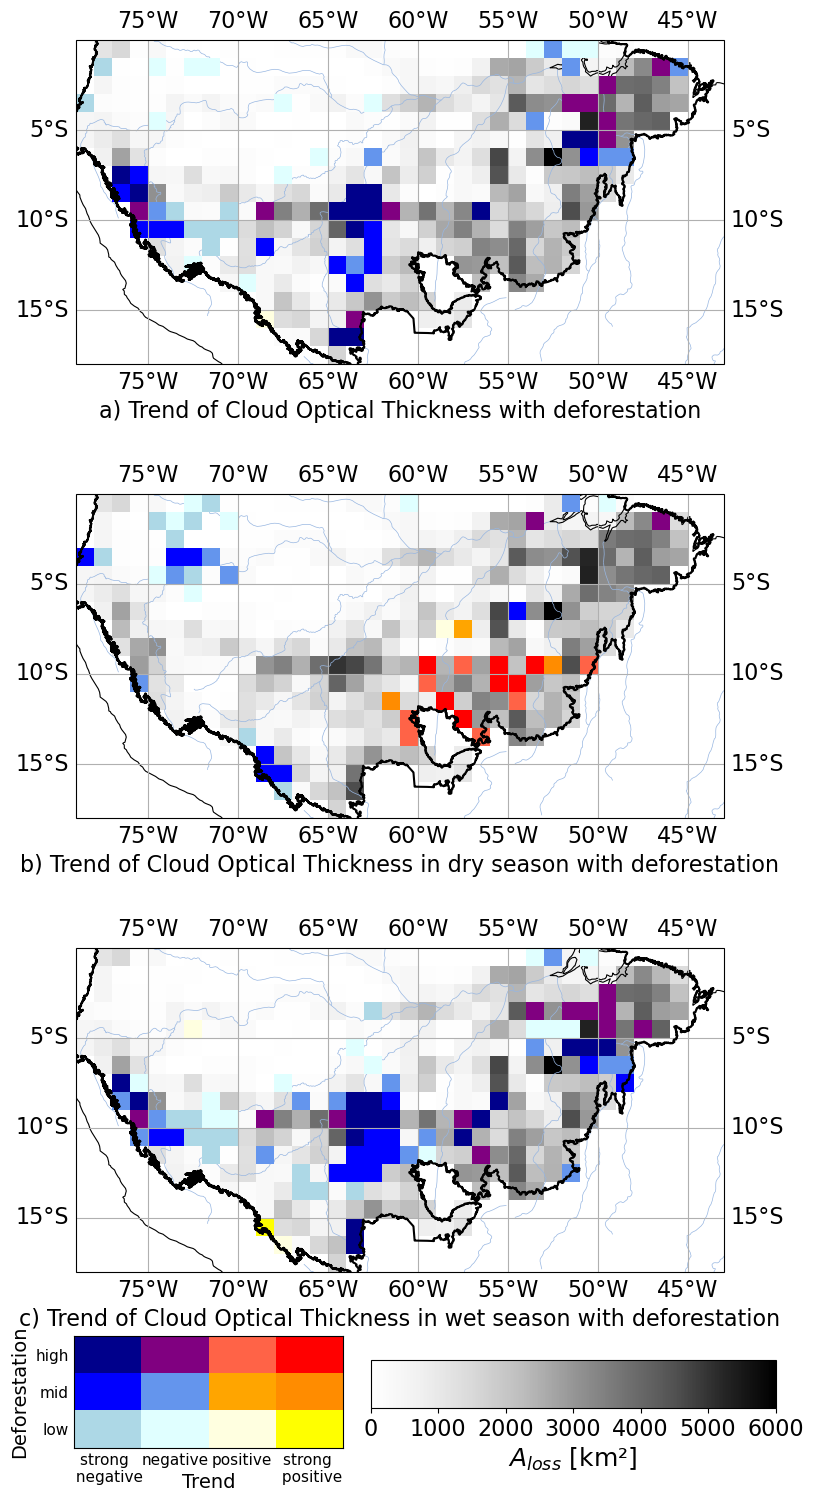

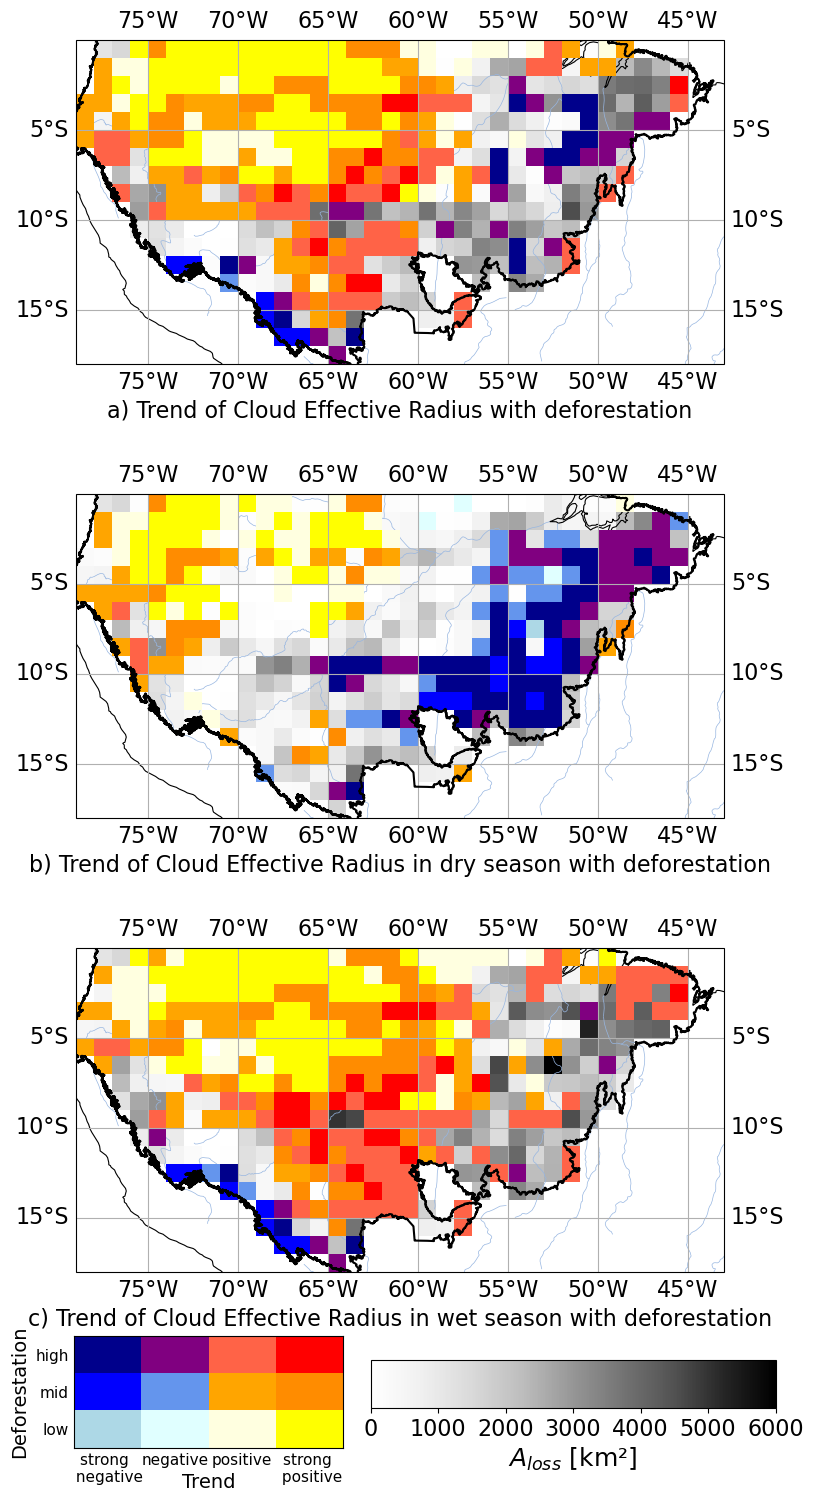

In [30]:
combi_biv(sets, sy=2003, ey=2023 )

### Alle Plots - ohne Varianz der Start- und Endzeitpunkte

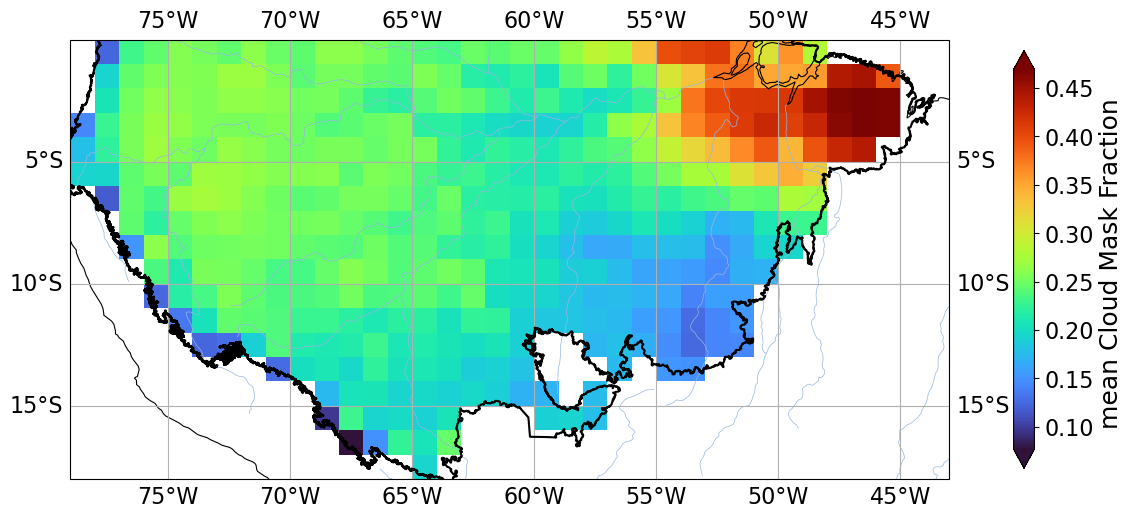

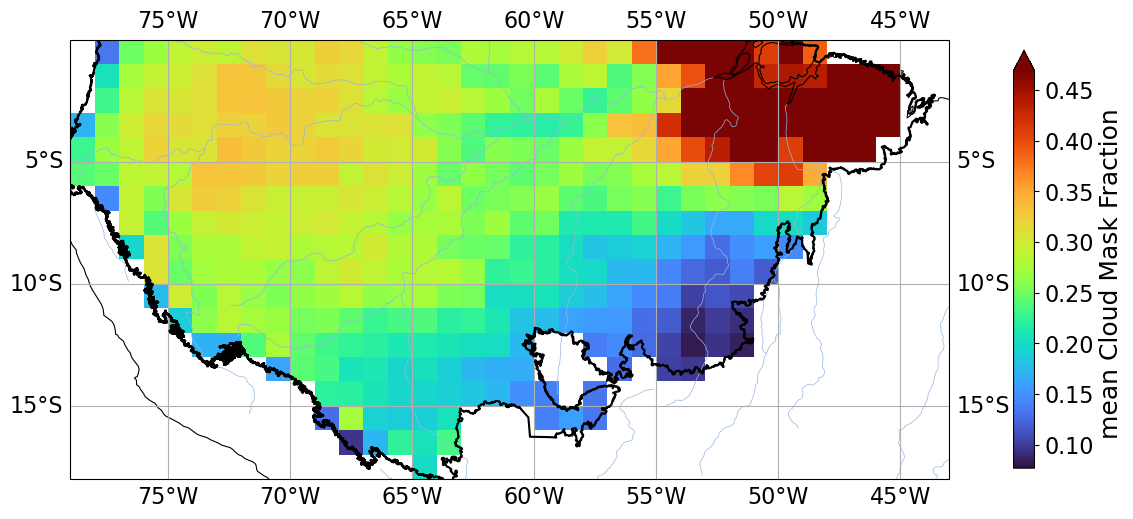

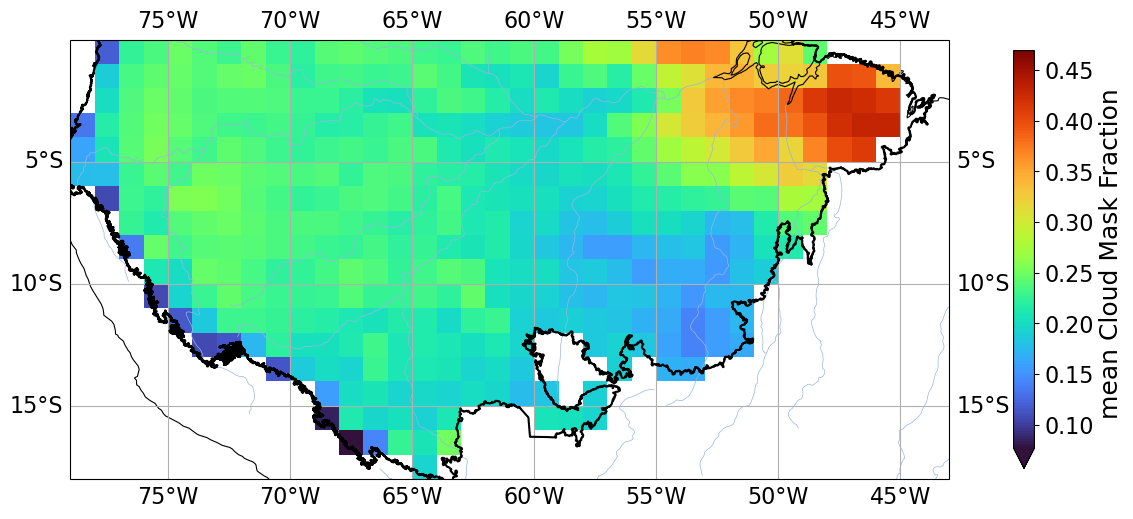

In [160]:
for nc in ['CMF_low.nc']:#, 'CWP_liq.nc','COT_liq.nc', 'CPS_liq.nc']: #'COT_liq_PCL.nc', 'CPS_liq_PCL.nc','CWP_liq_PCL.nc' ],
    for seas in ['off', 'dry', 'wet']:
        analyze_modis(nc, 'mean_avg', season=seas, start =f'2002-01-01', end =f'2024-12-31', plots=True, biv=False ,correlation=False)

#for nc in ['CWP_liq.nc','CMF_low.nc', 'COT_liq.nc', 'CPS_liq.nc']:
#    Diff_plot(nc, start='2002-01-01', end='2024-12-31')

### Alle Plots mit variierenden Zeitpunkten zur Trendanalyse (ohne bivariate Maps)

In [247]:
vals=[ [] , [] , [] , [] ]
for n, nc in enumerate(['CMF_low.nc', 'COT_liq.nc', 'CPS_liq.nc','CWP_liq.nc']):
    dset=[[],[],[]]
    for s, seas in enumerate(['off', 'dry', 'wet']):
        ses=[]
        for sy in [2002,2003,2004,2005,2006]:
            for ey in [2026,2025,2024,2023,2022]:
                avg=analyze_modis(nc, 'trend_Mean', season= seas, start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)
                ses.append(avg)
        dset[s].append(ses)
    vals[n].append(dset)  
print(vals)

CMF=np.array(vals[0])
COT=np.array(vals[1])
CPS=np.array(vals[2])
CWP=np.array(vals[3])

print(CMF)

[[[[[-0.0003069615421358211, 0.000556108527421981, 0.002249489660007205, 0.0005936174219840295, 0.001165460139261413, 0.0006744573482091404, 0.0015921825140296445, 0.003460612268424376, 0.0018419766126135427, 0.002572229429950436, 0.0019808707803436847, 0.0030085070831954506, 0.005205180100751255, 0.0036029278227297594, 0.0046146634879439125, 0.0024729006961456777, 0.003611132284476431, 0.006100092067154023, 0.004415167026442206, 0.005637739865333939, 0.002338338961000879, 0.0035914071380790612, 0.006352451053117106, 0.004495850361674746, 0.005875046180879747]], [[-0.0036334122980200816, -0.0036334122980200816, -0.001755426401534106, -0.0054350666145856685, -0.006156442667820091, -0.0030128194518883123, -0.0030128194518883123, -0.0009034552021313555, -0.004852280427361463, -0.005584644108204739, -0.0028366674190378393, -0.0028366674190378393, -0.000500024029578596, -0.004824283542770629, -0.005636683828428153, -0.0017419863593986992, -0.0017419863593986992, 0.0009560972177045065, -0.00

### RMSE

In [67]:
nc= ['CMF_low.nc', 'COT_liq.nc', 'CPS_liq.nc', 'CWP_liq.nc']
datasets = ['CMF', 'COT', 'CPS', 'LWP']
seasons = ['off', 'dry', 'wet']
shape = (len(datasets), len(seasons), 5)

ds_rmse = xr.Dataset(
    {
        'RMSE': (['dataset', 'season', 'variant'], np.full(shape, np.nan)),
    },
    coords={
        'dataset': datasets,
        'season': seasons,
        'variant': ['no_El','El_El', 'El_La', 'La_El', 'La_La']
    }
)
sy=2002
ey=2024

for nc, ds_name in zip(nc, datasets):
    for seas in seasons:
        
        GL= analyze_modis(nc, 'trend_Mean', season=seas, start =f'{sy}-01-01', end =f'{ey}-12-31', plots=False)[1] #no_LA
        no_El= analyze_modis(nc, 'trend_Mean', season=seas, start =f'{sy}-01-01', end =f'{ey-1}-12-31', plots=False)[1]
        
        El_El= analyze_modis(nc, 'trend_Mean', season=seas, start =f'{sy+1}-01-01', end =f'{ey-1}-12-31', plots=False)[1]
        El_La= analyze_modis(nc, 'trend_Mean', season=seas, start =f'{sy+1}-01-01', end =f'{ey}-12-31', plots=False)[1]
        
        La_El= analyze_modis(nc, 'trend_Mean', season=seas, start =f'{sy+4}-01-01', end =f'{ey-1}-12-31', plots=False)[1]
        La_La= analyze_modis(nc, 'trend_Mean', season=seas, start =f'{sy+4}-01-01', end =f'{ey}-12-31', plots=False)[1]

        
        for vers in [GL, El_El, El_La , La_El]:
            vers['mask']=amz_mask
            vers['trend_Mean']=vers['trend_Mean'].where(vers.mask==True)
            
        n=int(GL['trend_Mean'].count().values)

        RMSE1= np.sqrt( ((no_El.trend_Mean-GL.trend_Mean)**2).sum(skipna=True) / n )
        
        RMSE2= np.sqrt( ((El_El.trend_Mean-GL.trend_Mean)**2).sum(skipna=True) / n )
        RMSE3= np.sqrt( ((El_La.trend_Mean-GL.trend_Mean)**2).sum(skipna=True) / n )
        
        RMSE4= np.sqrt( ((La_El.trend_Mean-GL.trend_Mean)**2).sum(skipna=True) / n )
        RMSE5= np.sqrt( ((La_La.trend_Mean-GL.trend_Mean)**2).sum(skipna=True) / n )
        

        ds_rmse['RMSE'].loc[dict(dataset=ds_name, season=seas, variant='no_El')] = RMSE1
        
        ds_rmse['RMSE'].loc[dict(dataset=ds_name, season=seas, variant='El_El')] = RMSE2
        ds_rmse['RMSE'].loc[dict(dataset=ds_name, season=seas, variant='El_La')] = RMSE3
        
        ds_rmse['RMSE'].loc[dict(dataset=ds_name, season=seas, variant='La_El')] = RMSE4 
        ds_rmse['RMSE'].loc[dict(dataset=ds_name, season=seas, variant='La_La')] = RMSE5 

        print(f'{nc} + {seas} done') 

CMF_low.nc + off done
CMF_low.nc + dry done
CMF_low.nc + wet done
COT_liq.nc + off done
COT_liq.nc + dry done
COT_liq.nc + wet done
CPS_liq.nc + off done
CPS_liq.nc + dry done
CPS_liq.nc + wet done
CWP_liq.nc + off done
CWP_liq.nc + dry done
CWP_liq.nc + wet done


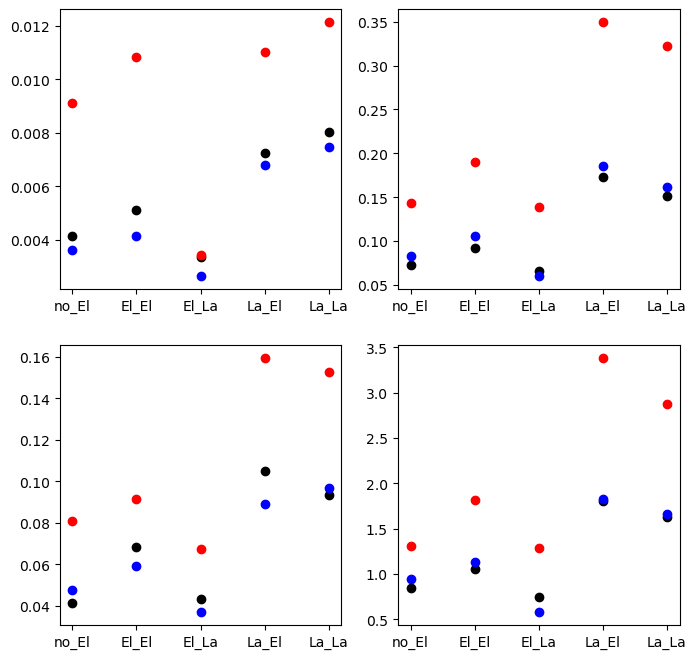

In [68]:
fig, axs = plt.subplots(2, 2, figsize=(8,8 ))
colors=['black','red','blue']

for ax, se in zip(axs.flat, datasets):
    for s, seas in enumerate(seasons):
        gds = ds_rmse.sel(dataset=se, season=seas)
        ax.scatter(gds.variant, gds.RMSE, color=colors[s])
        #ax.set_xticks(['2002-2023','2003-2023', '2003-2024', '2006-2023', '2006-2024'])
    #ax.title(f'RMSE of {se}')

In [37]:
ds_rmse.to_netcdf('rmse_output.nc')

PermissionError: [Errno 13] Permission denied: '/home/oscholz/rmse_output.nc'